# Chapter 3 — Abstraction and Modeling

> **Prerequisites:** ch001 — Why Programmers Should Learn Mathematics; ch002 — Mathematics vs Programming Thinking
>
> **You will learn:**
> - What mathematical abstraction is and how it differs from code abstraction
> - The modeling pipeline: real world → simplified model → mathematical structure → computation
> - How to deliberately control the fidelity of a model
> - Why the same mathematical structure appears in wildly different domains
> - How to identify when two problems are secretly the same problem
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Abstraction in programming means: hide implementation details behind an interface. A function call abstracts over the steps inside it. A class abstracts over data layout.

Abstraction in mathematics means something different: **identify the essential structure of a situation, stripped of all domain-specific detail**.

The difference matters. Programming abstraction manages complexity by hiding it. Mathematical abstraction manages complexity by *eliminating* it — by recognizing that two superficially different situations share the same underlying structure, so any theorem proved for that structure applies to both.

**Example of mathematical abstraction at work:**

These three problems look completely different:

1. A bank account earns 5% annual interest. How much is it worth after 20 years?
2. A bacterial colony doubles every 3 hours. How large is it after 24 hours?
3. A radioactive substance has a half-life of 10 years. How much remains after 50 years?

Strip away the domain. In all three cases, the quantity at time $t$ satisfies:

$$Q(t) = Q_0 \cdot r^t$$

where $r$ is a growth/decay factor. That is the mathematical structure. Once you have identified it, you solve all three with one formula.

**Modeling** is the process of deliberately constructing this mapping — from a real situation to a mathematical structure — with full awareness of what you are keeping and what you are throwing away.

**Common misconception:** A model is only useful if it is accurate.

Wrong. A model is useful if it captures the aspects of a situation that matter for the question being asked, while being simple enough to reason about. A perfect model is just a copy of reality — which is useless.

## 2. Intuition & Mental Models

**Physical analogy:** A map is an abstraction of terrain. A subway map throws away almost everything — elevation, street layout, distance — and keeps only one thing: which stations connect to which. That stripped-down model is precisely what makes it useful for navigating a subway. A topographically accurate map would be a worse tool for the same task. The fidelity of a model should match the question being asked.

**Computational analogy:** Think of a type signature. The signature `sort: List[int] -> List[int]` abstracts away everything about *how* the sorting is done — it captures only the input/output relationship. That abstraction lets you reason about a program that uses sorting without caring whether the sort is merge sort, quicksort, or timsort. Mathematical abstraction does the same thing at a higher level: it captures the structural relationship between quantities, independent of what those quantities represent physically.

**The abstraction ladder:**

```
Level 4 (most abstract): A function f: ℝ → ℝ with f(t) = a·bᵗ
Level 3 (mathematical):  Exponential growth with base b and initial value a
Level 2 (domain model):  Bank account with 5% annual interest
Level 1 (concrete):      This specific account with $1000, started January 2020
```

Moving up the ladder loses detail but gains generality. A result proven at Level 4 applies to everything below it.

Recall from ch002 that mathematical thinking is relational — it asks *what is true* rather than *how to compute*. The abstraction ladder is the spatial metaphor for that: at higher levels, you are describing *what kind of structure this is*, not *what specific values it takes*.

## 3. Visualization

We visualize the abstraction ladder directly: three superficially different scenarios that share the same mathematical structure. The point is to see the structural identity before being told it exists.

C:\Users\user\AppData\Local\Temp\ipykernel_21064\2982312597.py:91: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


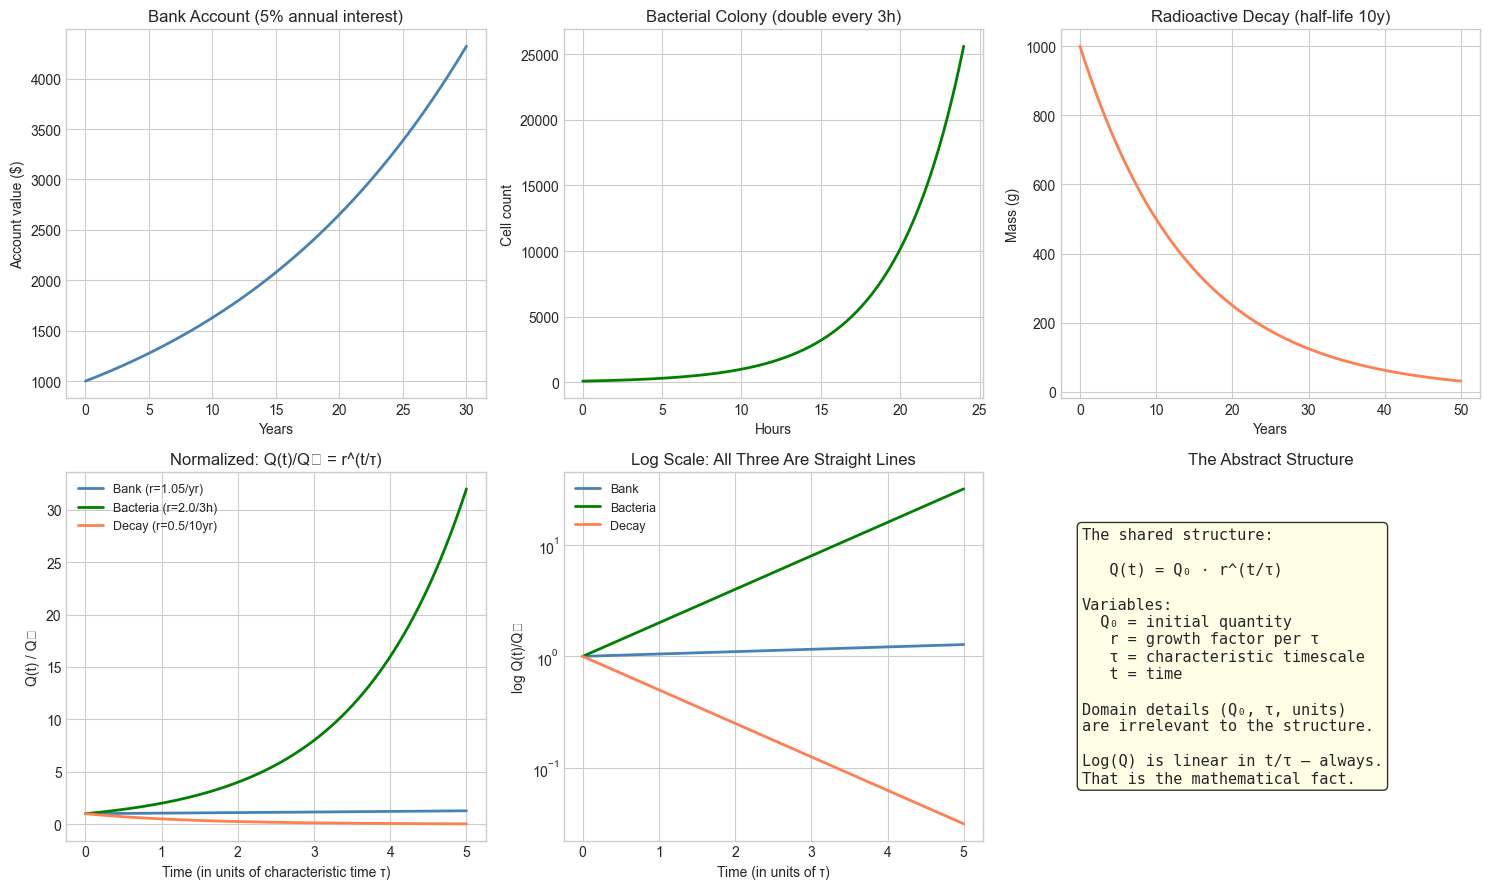

In [1]:
# --- Visualization: Three problems, one structure ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# --- Scenario parameters ---
# All three follow Q(t) = Q0 * r^t, but expressed in different units and domains

# 1. Bank account: $1000 at 5% annual interest, t in years
Q0_bank, r_bank = 1000.0, 1.05
t_bank = np.linspace(0, 30, 300)
Q_bank = Q0_bank * r_bank**t_bank

# 2. Bacteria: 100 cells, doubles every 3 hours, t in hours
Q0_bact, r_bact = 100.0, 2.0**(1/3)  # hourly growth rate for doubling every 3h
t_bact = np.linspace(0, 24, 300)
Q_bact = Q0_bact * r_bact**t_bact

# 3. Radioactive decay: 1000g, half-life 10 years, t in years
Q0_rad, r_rad = 1000.0, 0.5**(1/10)  # annual decay rate for 10-year half-life
t_rad = np.linspace(0, 50, 300)
Q_rad = Q0_rad * r_rad**t_rad

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Row 1: domain-specific view
axes[0, 0].plot(t_bank, Q_bank, 'steelblue', linewidth=2)
axes[0, 0].set_xlabel('Years')
axes[0, 0].set_ylabel('Account value ($)')
axes[0, 0].set_title('Bank Account (5% annual interest)')

axes[0, 1].plot(t_bact, Q_bact, 'green', linewidth=2)
axes[0, 1].set_xlabel('Hours')
axes[0, 1].set_ylabel('Cell count')
axes[0, 1].set_title('Bacterial Colony (double every 3h)')

axes[0, 2].plot(t_rad, Q_rad, 'coral', linewidth=2)
axes[0, 2].set_xlabel('Years')
axes[0, 2].set_ylabel('Mass (g)')
axes[0, 2].set_title('Radioactive Decay (half-life 10y)')

# Row 2: normalized view — strip away domain details
# Normalize: time in units of "characteristic time", quantity relative to Q0
tau_bank = 1.0          # 1 year
tau_bact = 3.0          # doubling time in hours
tau_rad  = 10.0         # half-life in years

t_norm = np.linspace(0, 5, 300)  # 0 to 5 characteristic times

# bank: r per tau = 1.05^1 = 1.05
# bact: r per tau = 2.0 (doubles each tau)
# rad:  r per tau = 0.5 (halves each tau)
axes[1, 0].plot(t_norm, 1.05**t_norm,  'steelblue', linewidth=2, label='Bank (r=1.05/yr)')
axes[1, 0].plot(t_norm, 2.0**t_norm,   'green',     linewidth=2, label='Bacteria (r=2.0/3h)')
axes[1, 0].plot(t_norm, 0.5**t_norm,   'coral',     linewidth=2, label='Decay (r=0.5/10yr)')
axes[1, 0].set_xlabel('Time (in units of characteristic time τ)')
axes[1, 0].set_ylabel('Q(t) / Q₀')
axes[1, 0].set_title('Normalized: Q(t)/Q₀ = r^(t/τ)')
axes[1, 0].legend(fontsize=9)

# Log scale reveals the shared linear structure
axes[1, 1].semilogy(t_norm, 1.05**t_norm,  'steelblue', linewidth=2, label='Bank')
axes[1, 1].semilogy(t_norm, 2.0**t_norm,   'green',     linewidth=2, label='Bacteria')
axes[1, 1].semilogy(t_norm, 0.5**t_norm,   'coral',     linewidth=2, label='Decay')
axes[1, 1].set_xlabel('Time (in units of τ)')
axes[1, 1].set_ylabel('log Q(t)/Q₀')
axes[1, 1].set_title('Log Scale: All Three Are Straight Lines')
axes[1, 1].legend(fontsize=9)

# Structure diagram
axes[1, 2].axis('off')
text = (
    "The shared structure:\n\n"
    "   Q(t) = Q₀ · r^(t/τ)\n\n"
    "Variables:\n"
    "  Q₀ = initial quantity\n"
    "   r = growth factor per τ\n"
    "   τ = characteristic timescale\n"
    "   t = time\n\n"
    "Domain details (Q₀, τ, units)\n"
    "are irrelevant to the structure.\n\n"
    "Log(Q) is linear in t/τ — always.\n"
    "That is the mathematical fact."
)
axes[1, 2].text(0.05, 0.5, text, transform=axes[1, 2].transAxes,
                fontsize=11, verticalalignment='center',
                fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 2].set_title('The Abstract Structure')

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

We now formalize the modeling pipeline. Given a real-world situation, constructing a mathematical model proceeds in four stages:

**Stage 1 — Identify the quantities.**

What changes? What stays fixed? What are we trying to predict or compute? Assign a symbol to each quantity and specify its type (real number, integer, vector, function, ...).

**Stage 2 — Identify the relationships.**

How do the quantities relate to each other? Express each relationship as an equation, inequality, or functional dependency.

**Stage 3 — Identify the structure.**

What kind of mathematical object is the system of relationships? Linear system? Differential equation? Graph? Probability distribution? This step is the abstraction step — it connects the specific problem to a general class that has been studied.

**Stage 4 — Solve and interpret.**

Apply the known tools for that structure. Translate the result back to the original domain.

**Formalized:**

Let $\mathcal{R}$ be the real-world situation. A model is a triple $(V, E, S)$ where:
- $V$ = set of variables with types
- $E$ = set of equations/constraints over $V$
- $S$ = the mathematical structure class $(V, E)$ belongs to

The model is valid for a question $Q$ if the answer to $Q$ about $\mathcal{R}$ equals the answer to $Q$ as formulated over $(V, E)$. This is *always approximate* — the question is whether the approximation is good enough for the purpose.

**Fidelity vs tractability tradeoff:**

$$\text{Model fidelity} \propto \text{complexity of } (V, E)$$
$$\text{Tractability} \propto \frac{1}{\text{complexity of } (V, E)}$$

There is no free lunch. Every additional variable or constraint added to the model increases its accuracy at the cost of computability. Good modeling is the art of choosing the right point on this tradeoff.

In [2]:
# --- Implementation: Modeling pipeline as a callable structure ---
# We encode the four-stage pipeline as a reusable class.
# This turns the abstract description into a concrete, runnable pattern.

import numpy as np

class MathModel:
    """
    A mathematical model encapsulating the four-stage modeling pipeline.
    
    Encodes:
        - quantities (variable names and their roles)
        - equations (the mathematical relationships)
        - a predict method that applies the model
        - a residual method that measures model error on data
    """
    
    def __init__(self, name, quantities, equation_fn, description=''):
        """
        Args:
            name:         model name (string)
            quantities:   dict mapping variable names to descriptions
            equation_fn:  callable(params, t) -> predicted value
            description:  human-readable description of what is being modeled
        """
        self.name = name
        self.quantities = quantities
        self.equation_fn = equation_fn
        self.description = description
        self.params = None  # set after fitting
    
    def fit(self, t_data, q_data, initial_params):
        """
        Fit model parameters to data by minimizing sum of squared residuals.
        Uses gradient-free search (grid search over 2-param models).
        
        Args:
            t_data:         array of time points
            q_data:         array of observed values
            initial_params: dict of initial parameter guesses
        """
        # Simple grid search for 2-parameter models
        # (We will do this properly with calculus in Part VII)
        param_names = list(initial_params.keys())
        assert len(param_names) == 2, "Grid search implemented for 2-param models only"
        
        p0_range = np.linspace(initial_params[param_names[0]] * 0.1,
                                initial_params[param_names[0]] * 3.0, 50)
        p1_range = np.linspace(initial_params[param_names[1]] * 0.5,
                                initial_params[param_names[1]] * 2.0, 50)
        
        best_loss = np.inf
        best_params = initial_params.copy()
        
        for p0 in p0_range:
            for p1 in p1_range:
                params = {param_names[0]: p0, param_names[1]: p1}
                pred = self.equation_fn(params, t_data)
                loss = np.sum((pred - q_data)**2)
                if loss < best_loss:
                    best_loss = loss
                    best_params = params.copy()
        
        self.params = best_params
        return self
    
    def predict(self, t):
        """
        Generate predictions at time points t.
        
        Args:
            t: scalar or array of time points
        Returns:
            Predicted values
        """
        assert self.params is not None, "Must call fit() before predict()"
        return self.equation_fn(self.params, t)
    
    def residuals(self, t_data, q_data):
        """
        Compute prediction errors on observed data.
        
        Args:
            t_data: observed time points
            q_data: observed values
        Returns:
            Array of residuals (observed - predicted)
        """
        return q_data - self.predict(t_data)
    
    def summary(self):
        """Print model description and fitted parameters."""
        print(f"Model: {self.name}")
        print(f"Description: {self.description}")
        print(f"Quantities: {self.quantities}")
        if self.params:
            print(f"Fitted parameters:")
            for k, v in self.params.items():
                print(f"  {k} = {v:.6g}")

# --- Demonstrate with the exponential growth model ---
np.random.seed(7)

# Generate noisy data from a known exponential process
TRUE_Q0 = 150.0
TRUE_R  = 1.08   # 8% growth per unit time
t_obs = np.array([0, 2, 4, 6, 8, 10, 12, 15, 20], dtype=float)
q_obs = TRUE_Q0 * TRUE_R**t_obs * (1 + 0.05 * np.random.randn(len(t_obs)))

# Define the exponential model
def exp_growth(params, t):
    """Q(t) = Q0 * r^t"""
    return params['Q0'] * params['r']**t

model = MathModel(
    name='Exponential Growth',
    quantities={'Q0': 'initial quantity', 'r': 'growth factor per unit time'},
    equation_fn=exp_growth,
    description='Q(t) = Q0 * r^t — models any proportional growth/decay'
)

model.fit(t_obs, q_obs, initial_params={'Q0': 100.0, 'r': 1.05})
model.summary()

print(f"\nTrue parameters: Q0={TRUE_Q0}, r={TRUE_R}")
print(f"RMSE: {np.sqrt(np.mean(model.residuals(t_obs, q_obs)**2)):.2f}")

Model: Exponential Growth
Description: Q(t) = Q0 * r^t — models any proportional growth/decay
Quantities: {'Q0': 'initial quantity', 'r': 'growth factor per unit time'}
Fitted parameters:
  Q0 = 169.796
  r = 1.07143

True parameters: Q0=150.0, r=1.08
RMSE: 29.51


## 5. Python Implementation

We now build a structure identifier — a program that, given a dataset, determines which mathematical model class fits it best. This operationalizes the central idea of abstraction: finding the right structural class for a situation.

In [3]:
# --- Implementation: Model structure identifier ---
# Given data (t, Q), determine whether the relationship is
# linear, quadratic, or exponential.
# Method: compare goodness-of-fit across structural classes.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def fit_linear(t, q):
    """
    Fit Q(t) = a*t + b using least squares.
    
    Returns:
        (params, r_squared): fitted parameters and R² score
    """
    # Build design matrix [t, 1]
    A = np.column_stack([t, np.ones_like(t)])
    # Least squares: solve A @ [a,b] ≈ q
    coeffs, _, _, _ = np.linalg.lstsq(A, q, rcond=None)
    a, b = coeffs
    q_pred = a * t + b
    ss_res = np.sum((q - q_pred)**2)
    ss_tot = np.sum((q - q.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    return {'a': a, 'b': b}, r2

def fit_quadratic(t, q):
    """
    Fit Q(t) = a*t² + b*t + c using least squares.
    
    Returns:
        (params, r_squared)
    """
    A = np.column_stack([t**2, t, np.ones_like(t)])
    coeffs, _, _, _ = np.linalg.lstsq(A, q, rcond=None)
    a, b, c = coeffs
    q_pred = a * t**2 + b * t + c
    ss_res = np.sum((q - q_pred)**2)
    ss_tot = np.sum((q - q.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    return {'a': a, 'b': b, 'c': c}, r2

def fit_exponential(t, q):
    """
    Fit Q(t) = Q0 * r^t by fitting log(Q) = log(Q0) + t*log(r) linearly.
    Requires q > 0.
    
    Returns:
        (params, r_squared) where r_squared is on the log scale
    """
    if np.any(q <= 0):
        return None, -np.inf
    log_q = np.log(q)
    A = np.column_stack([t, np.ones_like(t)])
    coeffs, _, _, _ = np.linalg.lstsq(A, log_q, rcond=None)
    log_r, log_Q0 = coeffs
    params = {'Q0': np.exp(log_Q0), 'r': np.exp(log_r)}
    q_pred = params['Q0'] * params['r']**t
    ss_res = np.sum((q - q_pred)**2)
    ss_tot = np.sum((q - q.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    return params, r2

def identify_structure(t, q, verbose=True):
    """
    Identify the best-fitting mathematical structure for (t, q) data.
    
    Args:
        t: array of independent variable values
        q: array of observed values
        verbose: if True, print comparison table
    Returns:
        (best_structure_name, params, r_squared)
    """
    t = np.array(t, dtype=float)
    q = np.array(q, dtype=float)
    
    candidates = {
        'linear':      fit_linear(t, q),
        'quadratic':   fit_quadratic(t, q),
        'exponential': fit_exponential(t, q),
    }
    
    if verbose:
        print(f"{'Structure':<15} {'R²':>8}")
        print("-" * 26)
        for name, (params, r2) in candidates.items():
            print(f"{name:<15} {r2:>8.6f}")
    
    best_name = max(candidates, key=lambda k: candidates[k][1])
    best_params, best_r2 = candidates[best_name]
    
    if verbose:
        print(f"\nBest fit: {best_name}  (R² = {best_r2:.6f})")
    
    return best_name, best_params, best_r2

# --- Test on known structures ---
t = np.linspace(1, 10, 15)
np.random.seed(3)
noise = lambda: 0.03 * np.random.randn(len(t))

datasets = {
    'True linear (3t + 2)':       3 * t + 2 + 5*noise(),
    'True quadratic (t² - t)':    t**2 - t + 3*noise(),
    'True exponential (2 * 1.3ᵗ)': 2 * 1.3**t * (1 + noise()),
}

for name, q_data in datasets.items():
    print(f"\n=== Dataset: {name} ===")
    identify_structure(t, q_data)


=== Dataset: True linear (3t + 2) ===
Structure             R²
--------------------------
linear          0.999705
quadratic       0.999813
exponential     0.928239

Best fit: quadratic  (R² = 0.999813)

=== Dataset: True quadratic (t² - t) ===
Structure             R²
--------------------------
linear          0.942843
quadratic       0.999994
exponential         -inf

Best fit: quadratic  (R² = 0.999994)

=== Dataset: True exponential (2 * 1.3ᵗ) ===
Structure             R²
--------------------------
linear          0.909613
quadratic       0.995850
exponential     0.997948

Best fit: exponential  (R² = 0.997948)


## 6. Experiments

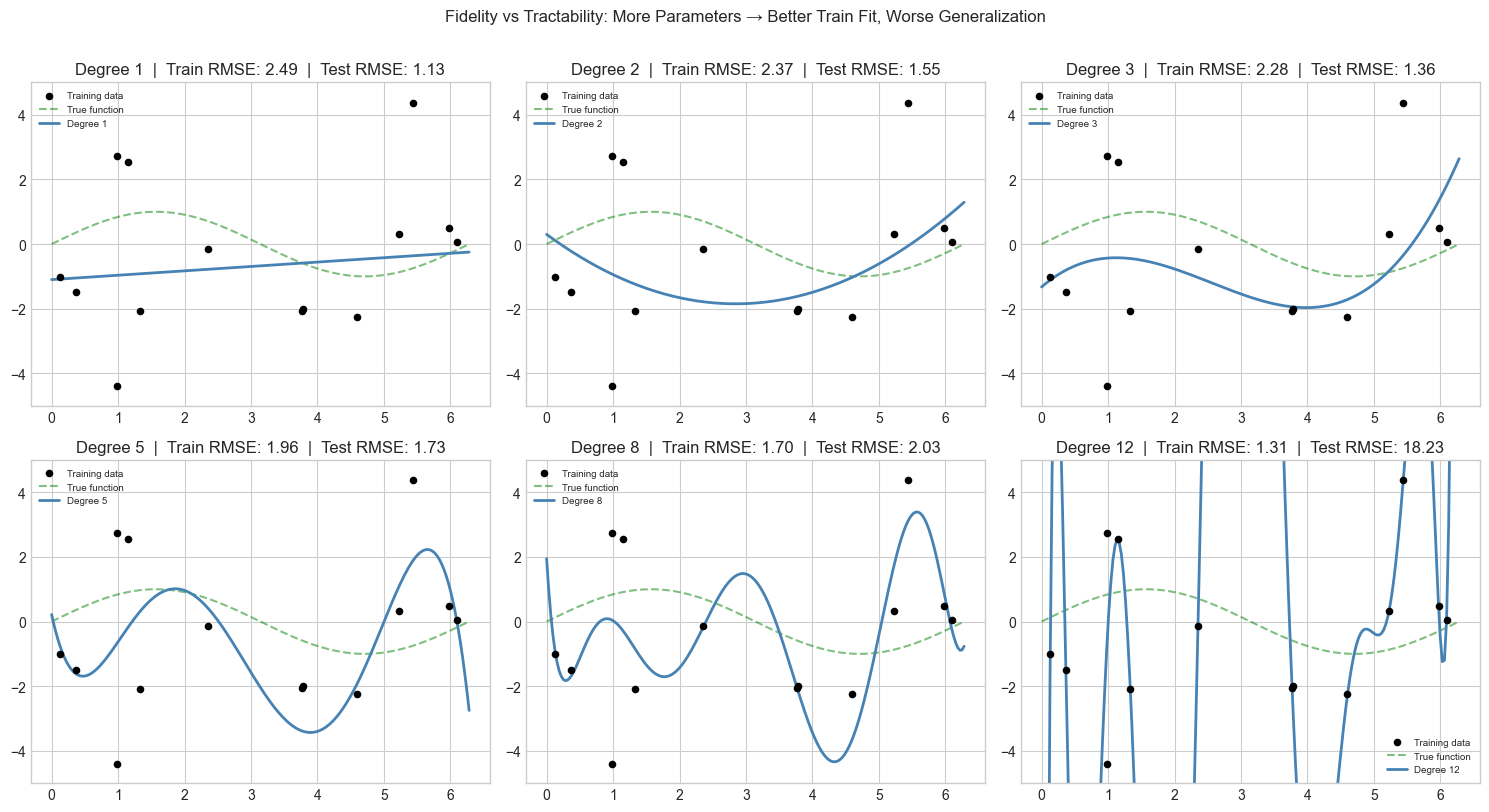

  Degree    Train RMSE     Test RMSE
------------------------------------
       1        2.4906        1.1323
       2        2.3694        1.5510
       3        2.2769        1.3617
       5        1.9613        1.7272
       8        1.6989        2.0298
      12        1.3090       18.2252 <-- overfitting


In [4]:
# --- Experiment 1: Fidelity vs Tractability ---
# Hypothesis: Adding more variables to a model always improves fit on training data,
# but eventually hurts prediction on new data (overfitting).
# Try changing: NOISE_LEVEL and N_POINTS to see when the tradeoff shifts.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

NOISE_LEVEL = 2.0   # <-- try: 0.1, 1.0, 5.0
N_POINTS = 15       # <-- try: 8, 20, 50
TRUE_FN = lambda t: np.sin(t)  # the true underlying function

np.random.seed(42)
t_train = np.sort(np.random.uniform(0, 2 * np.pi, N_POINTS))
q_train = TRUE_FN(t_train) + NOISE_LEVEL * np.random.randn(N_POINTS)

t_test = np.linspace(0, 2 * np.pi, 200)
q_test_true = TRUE_FN(t_test)

DEGREES = [1, 2, 3, 5, 8, 12]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

train_errors = []
test_errors  = []

for ax, degree in zip(axes.flat, DEGREES):
    # Fit polynomial of given degree
    coeffs = np.polyfit(t_train, q_train, degree)
    p = np.poly1d(coeffs)
    
    # Compute errors
    train_rmse = np.sqrt(np.mean((q_train - p(t_train))**2))
    test_rmse  = np.sqrt(np.mean((q_test_true - p(t_test))**2))
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)
    
    ax.scatter(t_train, q_train, color='black', s=20, zorder=5, label='Training data')
    ax.plot(t_test, q_test_true, 'g--', alpha=0.5, label='True function')
    ax.plot(t_test, p(t_test), 'steelblue', linewidth=2, label=f'Degree {degree}')
    ax.set_ylim(-5, 5)
    ax.set_title(f'Degree {degree}  |  Train RMSE: {train_rmse:.2f}  |  Test RMSE: {test_rmse:.2f}')
    ax.legend(fontsize=7)

plt.suptitle('Fidelity vs Tractability: More Parameters → Better Train Fit, Worse Generalization',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f"{'Degree':>8}  {'Train RMSE':>12}  {'Test RMSE':>12}")
print("-" * 36)
for deg, tr, te in zip(DEGREES, train_errors, test_errors):
    marker = " <-- overfitting" if te > 2 * min(test_errors) else ""
    print(f"{deg:>8}  {tr:>12.4f}  {te:>12.4f}{marker}")

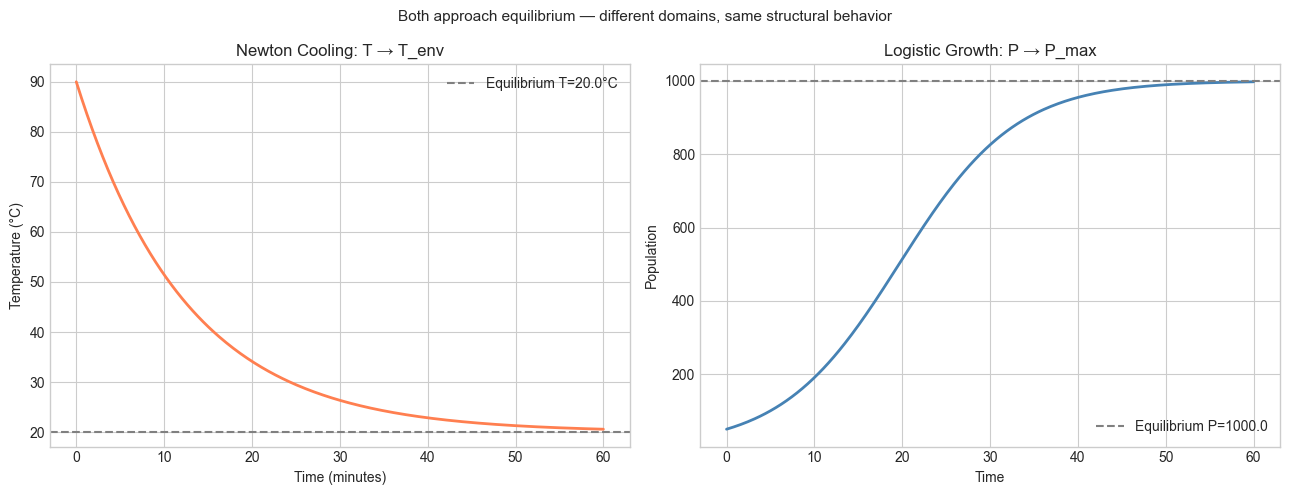

Both systems share: Q(t) → Q_equilibrium as t → ∞
The equilibrium is determined by the physics/biology — not by the math.
The rate of approach is the parameter that differs between domains.


In [5]:
# --- Experiment 2: The same structure in a different domain ---
# Hypothesis: Newton's law of cooling and population growth share
# the same mathematical structure (exponential approach to equilibrium).
# Try changing: EQUILIBRIUM_TEMP and COOLING_RATE

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Newton's law of cooling: T(t) = T_env + (T0 - T_env) * e^(-k*t)
# This is Q(t) = A + B * r^t where A = T_env, B = T0 - T_env, r = e^(-k)

T_ENV = 20.0         # <-- environment temperature (°C)
T0    = 90.0         # initial temperature
K     = 0.08         # <-- cooling rate (try: 0.02, 0.15)

t = np.linspace(0, 60, 300)
T_cool = T_ENV + (T0 - T_ENV) * np.exp(-K * t)

# Logistic growth: P(t) = K / (1 + ((K-P0)/P0) * e^(-r*t))
# This approaches an equilibrium from below
P_MAX = 1000.0  # carrying capacity
P0_pop = 50.0   # initial population
R_POP = 0.15    # growth rate
P_logistic = P_MAX / (1 + ((P_MAX - P0_pop) / P0_pop) * np.exp(-R_POP * t))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(t, T_cool, 'coral', linewidth=2)
axes[0].axhline(T_ENV, color='gray', linestyle='--', label=f'Equilibrium T={T_ENV}°C')
axes[0].set_xlabel('Time (minutes)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Newton Cooling: T → T_env')
axes[0].legend()

axes[1].plot(t, P_logistic, 'steelblue', linewidth=2)
axes[1].axhline(P_MAX, color='gray', linestyle='--', label=f'Equilibrium P={P_MAX}')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Population')
axes[1].set_title('Logistic Growth: P → P_max')
axes[1].legend()

plt.suptitle('Both approach equilibrium — different domains, same structural behavior', fontsize=11)
plt.tight_layout()
plt.show()

# The abstract structure: Q(t) → Q_eq as t → ∞
# The rate is controlled by the decay/growth parameter
# The shared structure: "exponential approach to an equilibrium"
print("Both systems share: Q(t) → Q_equilibrium as t → ∞")
print("The equilibrium is determined by the physics/biology — not by the math.")
print("The rate of approach is the parameter that differs between domains.")

## 7. Exercises

**Easy 1.** Write the four modeling stages (identify quantities, identify relationships, identify structure, solve and interpret) for this problem: *A car travels at constant speed. How far does it go in 3 hours?* Name the variables, write the equation, and name the mathematical structure (linear function). *(Expected: written description + one line of Python)*

**Easy 2.** The `identify_structure` function uses R² to compare models. What does R² measure? Add a printout to the function that shows not just R² but also the residuals (observed minus predicted) for the best-fitting model. *(Expected: residual array printed or plotted)*

**Medium 1.** Apply the `identify_structure` function to the following real-world datasets — generate them as described, then run the identifier and check if it finds the right structure:
- The time for a ball to fall from height h: `t = sqrt(2h/g)` with g=9.8, h = 1 to 100 meters, noise level 0.05
- The area of a circle with radius r: `A = pi * r^2`, r = 1 to 20, noise level 0.5

*(Hint: for the falling ball, the input variable is h, the output is t — what structure is that?)*

**Medium 2.** Modify Experiment 1 to include a degree-1 fit (linear) and a degree-20 fit in the same plot. Observe the degree-20 fit on the edges of the domain. This is called Runge's phenomenon. What does it suggest about the relationship between model fidelity and domain coverage? *(Hint: plot t_test slightly beyond [0, 2π] to make the effect visible)*

**Hard.** The fidelity-tractability tradeoff in Experiment 1 is a specific instance of the bias-variance tradeoff in machine learning. High-degree polynomials have low bias (they can represent complex functions) but high variance (they are sensitive to noise). Write a function that plots the bias² and variance components of prediction error as a function of polynomial degree. You will need to generate multiple training sets (via different random seeds) and average across them. *(Challenge: the theoretical decomposition is MSE = bias² + variance + irreducible noise — implement all three components)*

## 8. Mini Project

**Population of Burkina Faso: Model Selection and Forecast**

Problem: Given historical population data, determine which mathematical model (linear, quadratic, or exponential) best describes the growth, fit it, and forecast to 2050. Explicitly model the assumptions being made and state where they are likely to break.

Model comparison on historical data:
  Linear:      R² = 0.9076
  Quadratic:   R² = 0.9928
  Exponential: R² = 0.9843



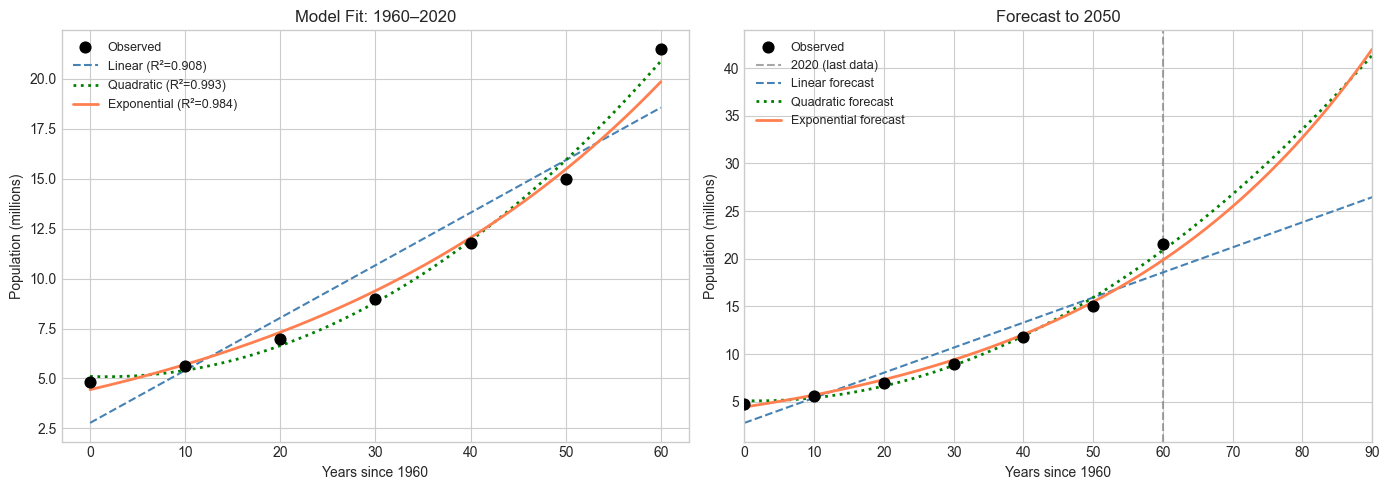

Forecasts for 2050 (population in millions):
  Linear:      26.5M
  Quadratic:   41.4M
  Exponential: 42.0M

Key assumptions and when they break:
  - Exponential assumes constant growth rate. Breaks when resources become limiting.
  - Linear assumes constant additive growth. Not biologically realistic.
  - Quadratic has no biological justification — just curve fitting.

A better model (ch080 — Logistic Growth Simulation) would include a carrying capacity.
That requires Part III functions. This is the limit of Part I modeling.


In [6]:
# --- Mini Project: Population Modeling and Forecast ---
# Problem: Model Burkina Faso population growth and forecast to 2050.
# Dataset: approximate historical values (World Bank estimates)
# Task: fit three model structures, select the best, forecast, state assumptions.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Historical population of Burkina Faso (millions, approximate)
# Source: World Bank / UN estimates
years = np.array([1960, 1970, 1980, 1990, 2000, 2010, 2020], dtype=float)
pop   = np.array([4.8,  5.6,  7.0,  9.0,  11.8, 15.0, 21.5], dtype=float)  # millions

# Normalize time (t=0 at 1960) for numerical stability
t = years - 1960

# --- Stage 1: Fit all three structures ---
lin_params,  lin_r2  = fit_linear(t, pop)
quad_params, quad_r2 = fit_quadratic(t, pop)
exp_params,  exp_r2  = fit_exponential(t, pop)

print("Model comparison on historical data:")
print(f"  Linear:      R² = {lin_r2:.4f}")
print(f"  Quadratic:   R² = {quad_r2:.4f}")
print(f"  Exponential: R² = {exp_r2:.4f}")
print()

# --- Stage 2: Forecast to 2050 ---
t_future = np.linspace(0, 90, 300)  # 1960 to 2050

lin_forecast  = lin_params['a']  * t_future + lin_params['b']
quad_forecast = (quad_params['a'] * t_future**2 +
                 quad_params['b'] * t_future + quad_params['c'])
exp_forecast  = exp_params['Q0'] * exp_params['r']**t_future

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: fitted models on historical range
t_hist = np.linspace(0, 60, 200)
axes[0].scatter(t, pop, color='black', s=60, zorder=5, label='Observed')
axes[0].plot(t_hist, lin_params['a']*t_hist + lin_params['b'],
             'steelblue', linestyle='--', label=f'Linear (R²={lin_r2:.3f})')
axes[0].plot(t_hist,
             quad_params['a']*t_hist**2 + quad_params['b']*t_hist + quad_params['c'],
             'green', linestyle=':', linewidth=2, label=f'Quadratic (R²={quad_r2:.3f})')
axes[0].plot(t_hist, exp_params['Q0'] * exp_params['r']**t_hist,
             'coral', linewidth=2, label=f'Exponential (R²={exp_r2:.3f})')
axes[0].set_xlabel('Years since 1960')
axes[0].set_ylabel('Population (millions)')
axes[0].set_title('Model Fit: 1960–2020')
axes[0].legend(fontsize=9)

# Right: forecasts to 2050
axes[1].scatter(t, pop, color='black', s=60, zorder=5, label='Observed')
axes[1].axvline(60, color='gray', linestyle='--', alpha=0.7, label='2020 (last data)')
axes[1].plot(t_future, lin_forecast,  'steelblue', linestyle='--', label='Linear forecast')
axes[1].plot(t_future, quad_forecast, 'green',     linestyle=':',  linewidth=2, label='Quadratic forecast')
axes[1].plot(t_future, exp_forecast,  'coral',     linewidth=2, label='Exponential forecast')
axes[1].set_xlabel('Years since 1960')
axes[1].set_ylabel('Population (millions)')
axes[1].set_title('Forecast to 2050')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 90)

plt.tight_layout()
plt.show()

# --- Stage 3: State assumptions and their breakdown points ---
year_2050 = 2050 - 1960
print("Forecasts for 2050 (population in millions):")
print(f"  Linear:      {lin_params['a']*year_2050 + lin_params['b']:.1f}M")
print(f"  Quadratic:   {quad_params['a']*year_2050**2 + quad_params['b']*year_2050 + quad_params['c']:.1f}M")
print(f"  Exponential: {exp_params['Q0'] * exp_params['r']**year_2050:.1f}M")
print()
print("Key assumptions and when they break:")
print("  - Exponential assumes constant growth rate. Breaks when resources become limiting.")
print("  - Linear assumes constant additive growth. Not biologically realistic.")
print("  - Quadratic has no biological justification — just curve fitting.")
print()
print("A better model (ch080 — Logistic Growth Simulation) would include a carrying capacity.")
print("That requires Part III functions. This is the limit of Part I modeling.")

## 9. Chapter Summary & Connections

**What was covered:**

- Mathematical abstraction strips domain-specific detail to reveal shared structure — enabling results proven once to apply everywhere that structure appears
- The modeling pipeline has four stages: identify quantities → identify relationships → identify structure → solve and interpret
- The fidelity-tractability tradeoff is fundamental: more complex models fit training data better but generalize worse
- The same mathematical structure (exponential approach to equilibrium) appears in cooling, population dynamics, and many other domains — recognizing the structure is the payoff of abstraction

**Forward connections:**

- The fidelity-tractability tradeoff seen in Experiment 1 is formally analyzed in ch285 — Bias and Variance, where it is quantified precisely for statistical learning models
- The structure identifier (linear / quadratic / exponential) is a primitive version of the model selection methods in ch283 — Model Evaluation; the R² metric used here will be derived from first principles using residuals and variance
- The population modeling mini project is extended in ch080 — Logistic Growth Simulation, which uses a carrying capacity parameter to model bounded growth — the exponential model's natural generalization

**Backward connection:**

- This chapter operationalizes ch002's central claim: relational thinking (identifying structure) precedes operational thinking (choosing a procedure). The `identify_structure` function is a mechanical version of that process — it searches over structural classes and selects the one that best fits the data. *(Introduced in ch002 — Mathematics vs Programming Thinking)*

**Going deeper:**

The formal theory of mathematical modeling is treated in George Box's phrase: "All models are wrong, but some are useful." Box and Draper's *Empirical Model-Building and Response Surfaces* gives the statistical foundation. For the philosophical side — what it means for a model to be adequate — see Patrick Suppes, *Studies in the Methodology and Foundations of Science*.